In [1]:
%pip install pandas matplotlib numpy jupyter

import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
print(os.getcwd())
print(os.listdir("../data"))

/Users/jalsuthar/dev/nem-min-demand-forecast/notebooks
['PRICE_AND_DEMAND_202601_SA1.csv', 'nem_combined_clean.csv', 'PRICE_AND_DEMAND_202606_SA1.csv', 'PRICE_AND_DEMAND_202601_NSW1.csv']


In [3]:
df = pd.read_csv("../data/PRICE_AND_DEMAND_202601_NSW1.csv")
df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2026/01/01 00:05:00,6713.88,71.24,TRADE
1,NSW1,2026/01/01 00:10:00,6751.48,65.31,TRADE
2,NSW1,2026/01/01 00:15:00,6715.71,69.28,TRADE
3,NSW1,2026/01/01 00:20:00,6659.29,58.40,TRADE
4,NSW1,2026/01/01 00:25:00,6628.90,57.30,TRADE


In [4]:
print(df.shape)
df.info()
df.describe()

(8928, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   REGION          8928 non-null   object 
 1   SETTLEMENTDATE  8928 non-null   object 
 2   TOTALDEMAND     8928 non-null   float64
 3   RRP             8928 non-null   float64
 4   PERIODTYPE      8928 non-null   object 
dtypes: float64(2), object(3)
memory usage: 348.9+ KB


,TOTALDEMAND,RRP
count,8928.000000,8928.000000
mean,7393.698602,67.221123
std,1498.056944,375.127837
min,4015.440000,-999.980000
25%,6449.717500,32.350000
50%,7153.525000,57.060000
75%,8011.175000,74.492500
max,13146.790000,11938.050000


In [5]:
df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   REGION          8928 non-null   object        
 1   SETTLEMENTDATE  8928 non-null   datetime64[ns]
 2   TOTALDEMAND     8928 non-null   float64       
 3   RRP             8928 non-null   float64       
 4   PERIODTYPE      8928 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 348.9+ KB


Matplotlib is building the font cache; this may take a moment.


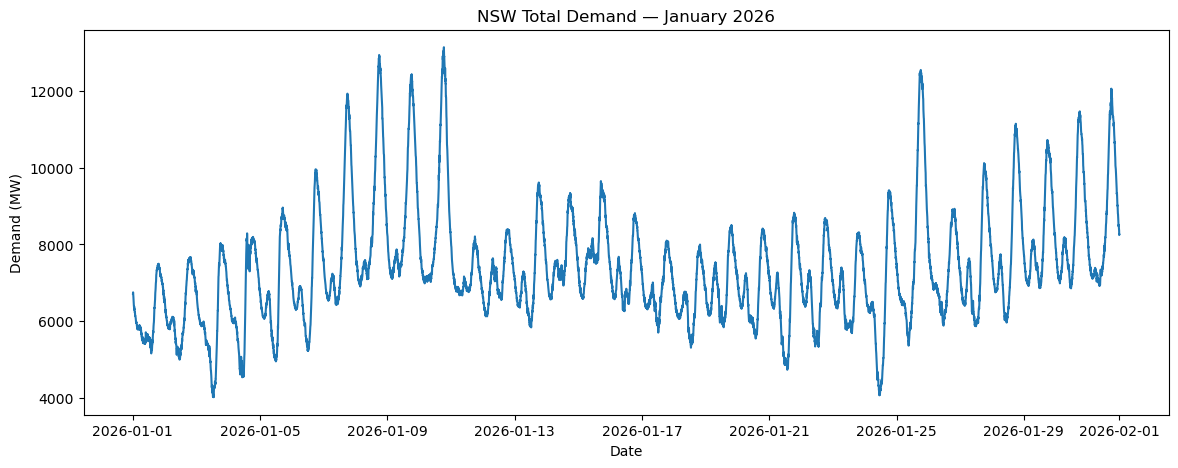

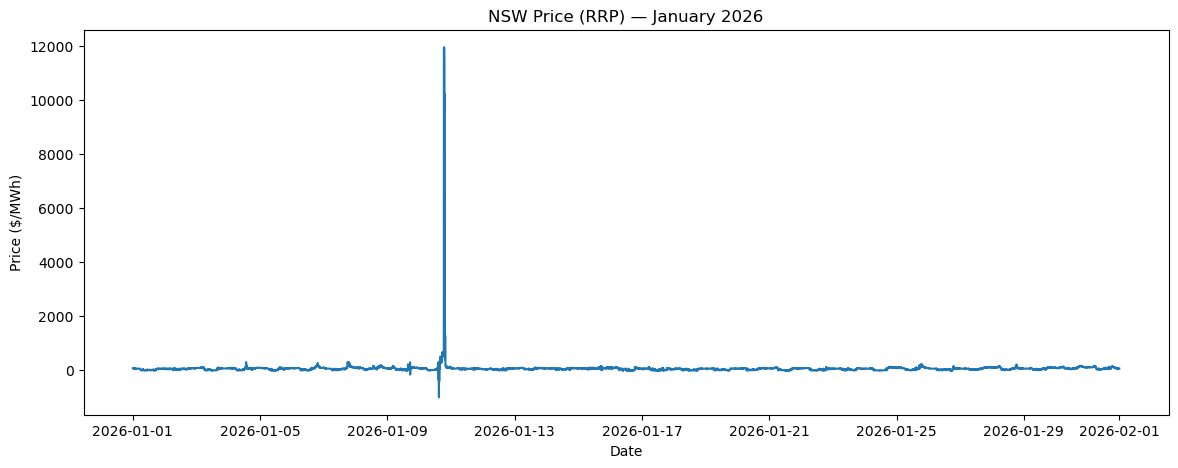

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df["SETTLEMENTDATE"], df["TOTALDEMAND"])
plt.title("NSW Total Demand — January 2026")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df["SETTLEMENTDATE"], df["RRP"])
plt.title("NSW Price (RRP) — January 2026")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.show()


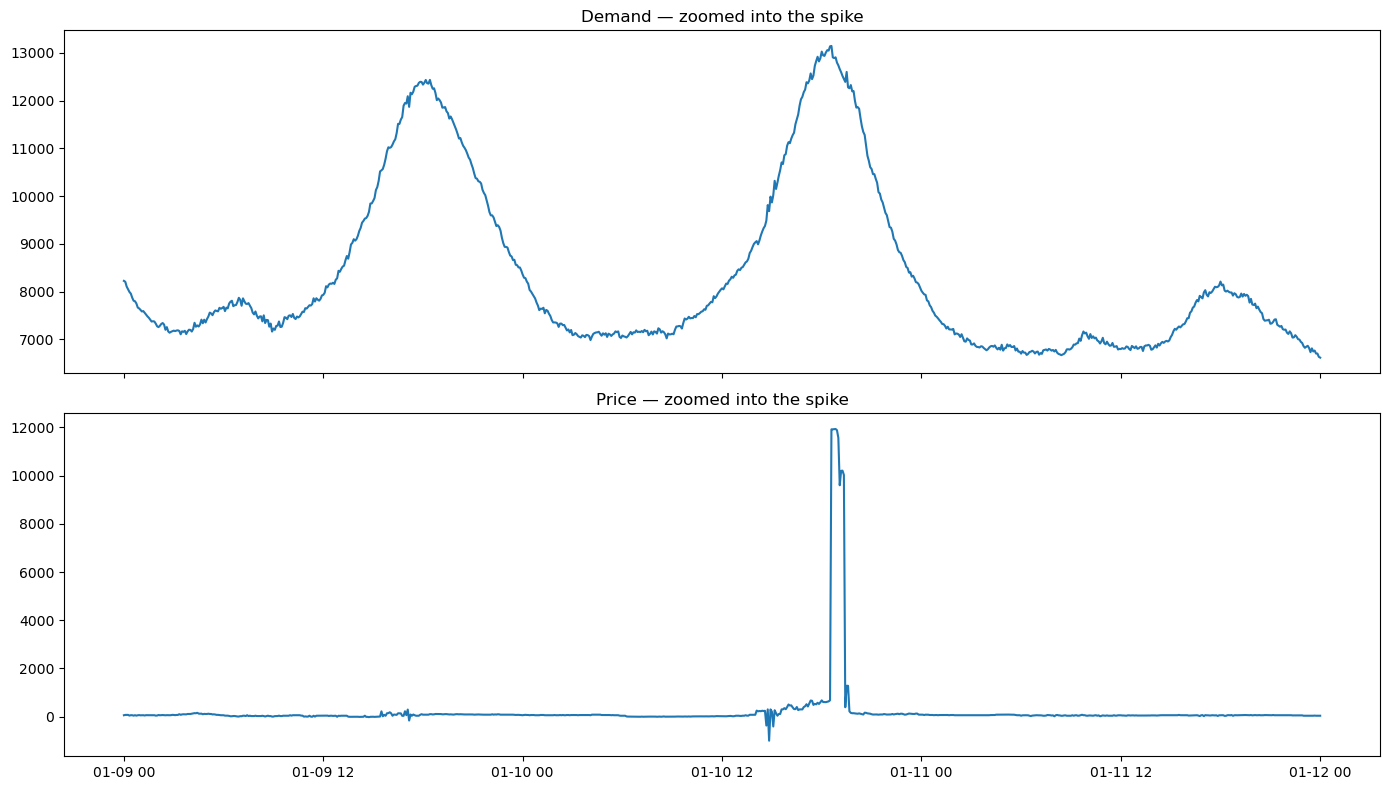

In [7]:
# lets zoom in to see the days and time where the spike occured 

spike_window = df[(df["SETTLEMENTDATE"] >= "2026-01-09") & (df["SETTLEMENTDATE"] <= "2026-01-12")]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(spike_window["SETTLEMENTDATE"], spike_window["TOTALDEMAND"])
axes[0].set_title("Demand — zoomed into the spike")
axes[1].plot(spike_window["SETTLEMENTDATE"], spike_window["RRP"])
axes[1].set_title("Price — zoomed into the spike")
plt.tight_layout()
plt.show()

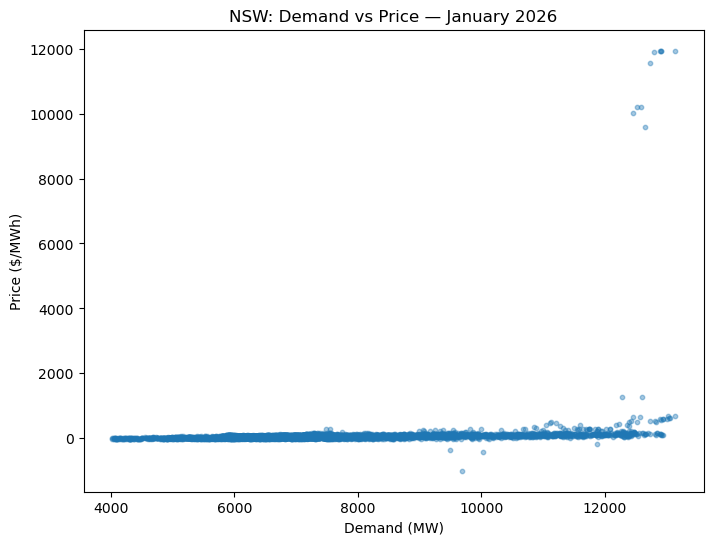

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(df["TOTALDEMAND"], df["RRP"], alpha=0.4, s=10)
plt.title("NSW: Demand vs Price — January 2026")
plt.xlabel("Demand (MW)")
plt.ylabel("Price ($/MWh)")
plt.show()

In [9]:
# Crossing the demand threshold enables a price spike but it doesnt cause one deterministically

# Plain regression wouldnt work here as it would badly underfit the spikes

In [10]:
df_sa = pd.read_csv("../data/PRICE_AND_DEMAND_202601_SA1.csv")
df_sa["SETTLEMENTDATE"] = pd.to_datetime(df_sa["SETTLEMENTDATE"])
df_sa.describe()

,SETTLEMENTDATE,TOTALDEMAND,RRP
count,8928,8928.000000,8928.000000
mean,2026-01-16 12:02:30,1405.975731,152.251626
min,2026-01-01 00:05:00,-169.330000,-325.000000
25%,2026-01-08 18:03:45,1117.665000,-7.000000
50%,2026-01-16 12:02:30,1445.350000,29.055000
75%,2026-01-24 06:01:15,1733.295000,78.887500
max,2026-02-01 00:00:00,3140.330000,20300.000000
std,NaN,600.102491,1340.911963


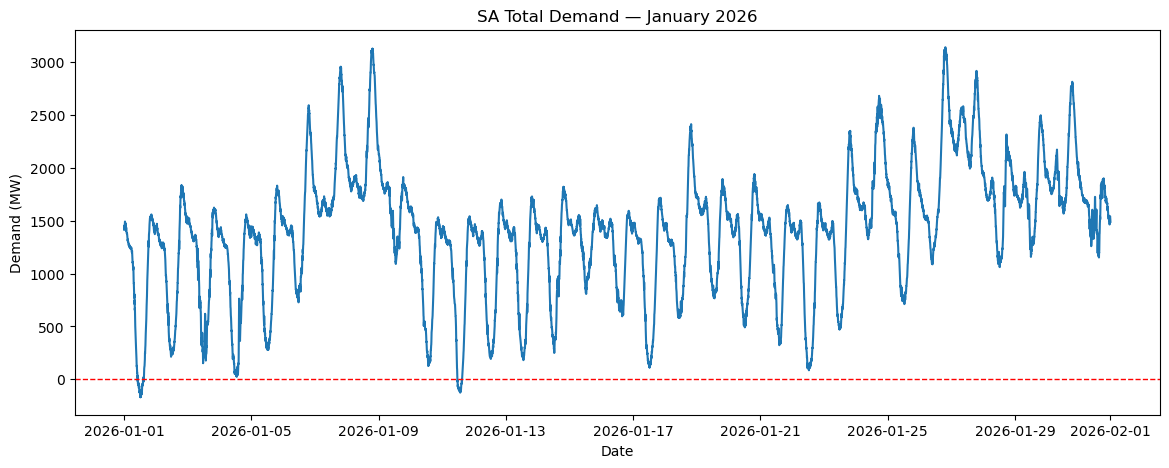

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df_sa["SETTLEMENTDATE"], df_sa["TOTALDEMAND"])
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("SA Total Demand — January 2026")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.show()

In [12]:
negative_demand = df_sa[df_sa["TOTALDEMAND"] < 0]
print(f"Number of negative-demand intervals: {len(negative_demand)}")
print(f"Worst (most negative) value: {df_sa['TOTALDEMAND'].min()} MW")
negative_demand[["SETTLEMENTDATE", "TOTALDEMAND"]]

Number of negative-demand intervals: 94
Worst (most negative) value: -169.33 MW


,SETTLEMENTDATE,TOTALDEMAND
123,2026-01-01 10:20:00,-17.99
124,2026-01-01 10:25:00,-8.99
125,2026-01-01 10:30:00,-40.49
126,2026-01-01 10:35:00,-38.70
127,2026-01-01 10:40:00,-56.39
...,...,...
3055,2026-01-11 14:40:00,-42.76
3056,2026-01-11 14:45:00,-27.08
3057,2026-01-11 14:50:00,-1.84
3058,2026-01-11 14:55:00,-18.60


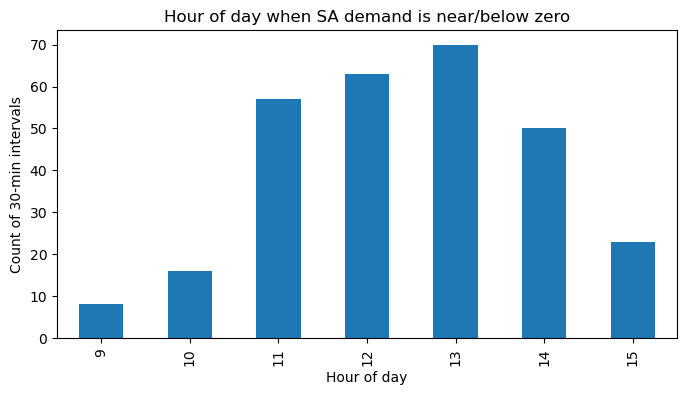

In [13]:
df_sa["hour"] = df_sa["SETTLEMENTDATE"].dt.hour
negative_demand_hours = df_sa[df_sa["TOTALDEMAND"] < 200]["hour"]  # near-zero troughs, not just true negatives

plt.figure(figsize=(8, 4))
negative_demand_hours.value_counts().sort_index().plot(kind="bar")
plt.title("Hour of day when SA demand is near/below zero")
plt.xlabel("Hour of day")
plt.ylabel("Count of 30-min intervals")
plt.show()

In [14]:
df_sa_winter = pd.read_csv("../data/PRICE_AND_DEMAND_202606_SA1.csv")  
df_sa_winter["SETTLEMENTDATE"] = pd.to_datetime(df_sa_winter["SETTLEMENTDATE"])

print("Winter negative-demand intervals:", (df_sa_winter["TOTALDEMAND"] < 0).sum())
print("Summer (Jan) negative-demand intervals:", (df_sa["TOTALDEMAND"] < 0).sum())

Winter negative-demand intervals: 0
Summer (Jan) negative-demand intervals: 94


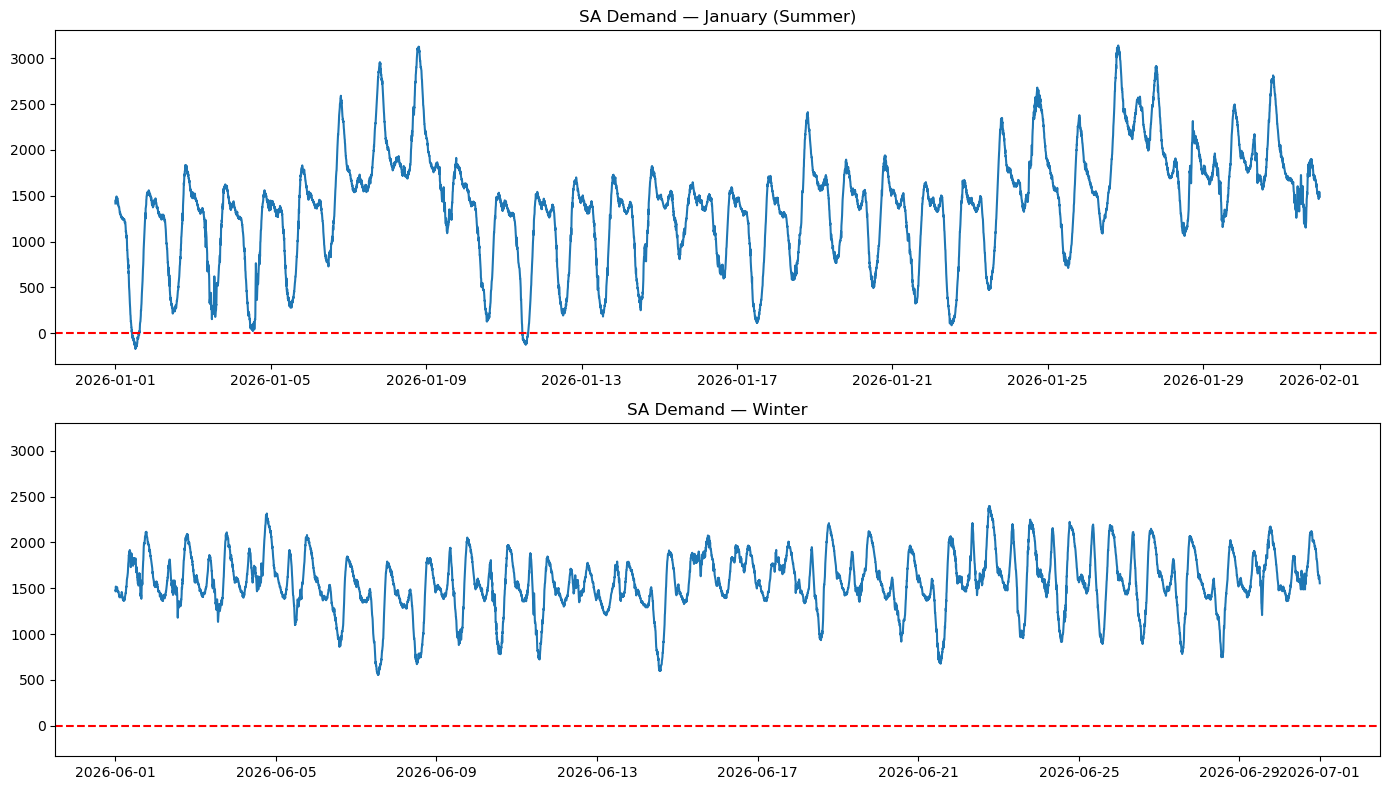

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharey=True)
axes[0].plot(df_sa["SETTLEMENTDATE"], df_sa["TOTALDEMAND"])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("SA Demand — January (Summer)")

axes[1].plot(df_sa_winter["SETTLEMENTDATE"], df_sa_winter["TOTALDEMAND"])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("SA Demand — Winter")
plt.tight_layout()
plt.show()

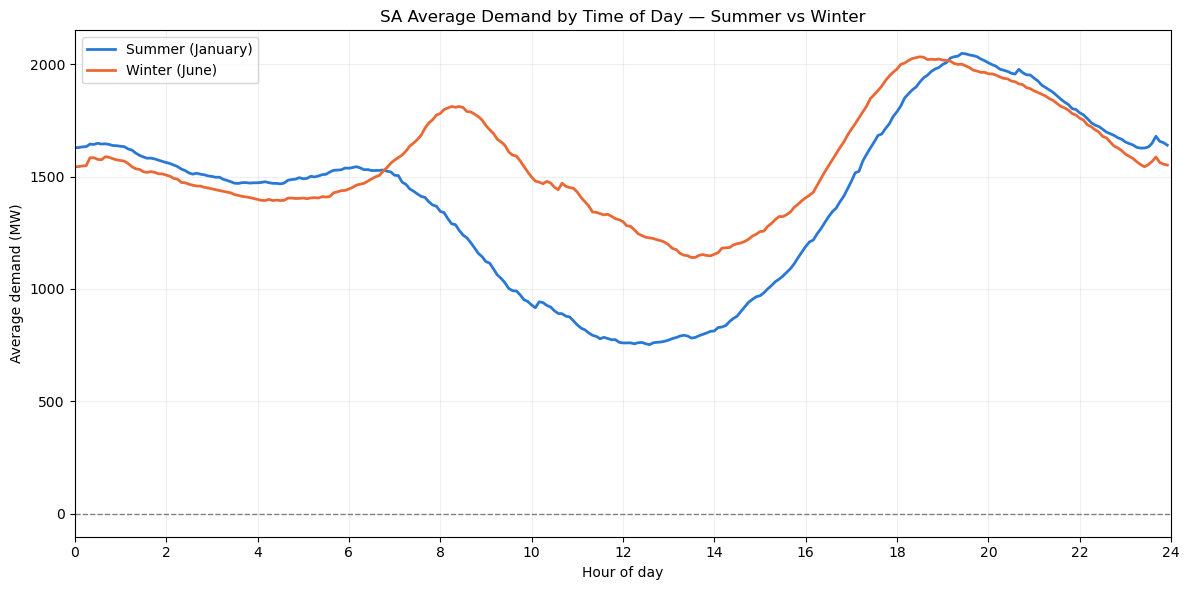

In [16]:
# Overlay summer vs winter: average SA demand profile by time of day
df_sa_winter["hour"] = df_sa_winter["SETTLEMENTDATE"].dt.hour

df_sa["time_of_day"] = df_sa["SETTLEMENTDATE"].dt.hour + df_sa["SETTLEMENTDATE"].dt.minute / 60
df_sa_winter["time_of_day"] = df_sa_winter["SETTLEMENTDATE"].dt.hour + df_sa_winter["SETTLEMENTDATE"].dt.minute / 60

summer_profile = df_sa.groupby("time_of_day")["TOTALDEMAND"].mean()
winter_profile = df_sa_winter.groupby("time_of_day")["TOTALDEMAND"].mean()

plt.figure(figsize=(12, 6))
plt.plot(summer_profile.index, summer_profile.values, color="#2a78d6", linewidth=2, label="Summer (January)")
plt.plot(winter_profile.index, winter_profile.values, color="#eb6834", linewidth=2, label="Winter (June)")
plt.axhline(0, color="grey", linestyle="--", linewidth=1)

plt.title("SA Average Demand by Time of Day — Summer vs Winter")
plt.xlabel("Hour of day")
plt.ylabel("Average demand (MW)")
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("hello world")